In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, classification_report

# Style global
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# Formateur roupies
def fmt_inr(x, _=None):
    return f"₹{x:,.0f}".replace(",", " ")

In [5]:
clean_data = pd.read_csv("Clean_Dataset.csv", index_col=0)
print(f"Données brutes : {clean_data.shape[0]:,} lignes × {clean_data.shape[1]} colonnes")

clean_data = clean_data.drop(columns=["flight", "arrival_time"])

clean_data = clean_data[clean_data["stops"] != "two_or_more"].copy()
print(f"Après suppression 2+ stops : {clean_data.shape[0]:,} lignes")

DESTINATIONS = ["Mumbai", "Delhi", "Chennai"]
df = clean_data[(clean_data["source_city"] == "Bangalore") &
         (clean_data["destination_city"].isin(DESTINATIONS))].copy()
print(f"Routes Bangalore→{{Mumbai,Delhi,Chennai}} : {df.shape[0]:,} lignes")
print()
df.info()

Données brutes : 300,153 lignes × 11 colonnes
Après suppression 2+ stops : 286,867 lignes
Routes Bangalore→{Mumbai,Delhi,Chennai} : 32,111 lignes

<class 'pandas.core.frame.DataFrame'>
Index: 32111 entries, 84065 to 261280
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           32111 non-null  object 
 1   source_city       32111 non-null  object 
 2   departure_time    32111 non-null  object 
 3   stops             32111 non-null  object 
 4   destination_city  32111 non-null  object 
 5   class             32111 non-null  object 
 6   duration          32111 non-null  float64
 7   days_left         32111 non-null  int64  
 8   price             32111 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 2.4+ MB


In [7]:
# Vérification doublons et valeurs manquantes
df = df.drop_duplicates()
print("Doublons restants :", df.duplicated().sum())

df.isna().sum()

Doublons restants : 0


airline             0
source_city         0
departure_time      0
stops               0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [10]:
# Distribution des stops par route
df.groupby(["destination_city", "stops"]).size().unstack(fill_value=0)

stops,one,zero
destination_city,,
Chennai,5427,417
Delhi,11307,1942
Mumbai,10962,1596


## 3. Feature Engineering

On crée des variables dérivées utiles pour les modèles et l'EDA :

In [11]:
time_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
time_enc   = {t: i for i, t in enumerate(time_order)}
df["departure_time_enc"] = df["departure_time"].map(time_enc)

df["est_direct"] = (df["stops"] == "zero").astype(int)

df["log_days_left"] = np.log1p(df["days_left"])
df["log_price"]     = np.log(df["price"])

df["prix_par_heure"] = df["price"] / df["duration"]

bins  = [0, 7, 15, 30, 50]
labels = ["Dernière minute (≤7j)", "Court terme (8-15j)", "Moyen terme (16-30j)", "Anticipé (31j+)"]
df["fenetre_reservation"] = pd.cut(df["days_left"], bins=bins, labels=labels, right=True)

Economy  = df[df["class"] == "Economy"].copy()
Business = df[df["class"] == "Business"].copy()

print(f"Economy  : {len(Economy):,} lignes")
print(f"Business : {len(Business):,} lignes")
Economy[["days_left", "log_days_left", "price", "log_price",
          "prix_par_heure", "est_direct", "departure_time_enc",
          "fenetre_reservation"]].describe().round(2)

Economy  : 21,523 lignes
Business : 10,128 lignes


,days_left,log_days_left,price,log_price,prix_par_heure,est_direct,departure_time_enc
count,21523.00,21523.00,21523.00,21523.00,21523.00,21523.00,21523.00
mean,26.07,3.11,6334.89,8.62,862.09,0.14,1.70
std,13.62,0.71,3491.72,0.50,705.53,0.35,1.44
min,1.00,0.69,1603.00,7.38,124.07,0.00,0.00
25%,15.00,2.77,4111.00,8.32,402.82,0.00,0.00
50%,26.00,3.30,5179.00,8.55,627.41,0.00,1.00
75%,38.00,3.66,7484.00,8.92,1109.33,0.00,3.00
max,49.00,3.91,40354.00,10.61,8327.00,1.00,5.00


## 4. Analyse exploratoire (EDA)
### 4.1 Distributions des variables numériques

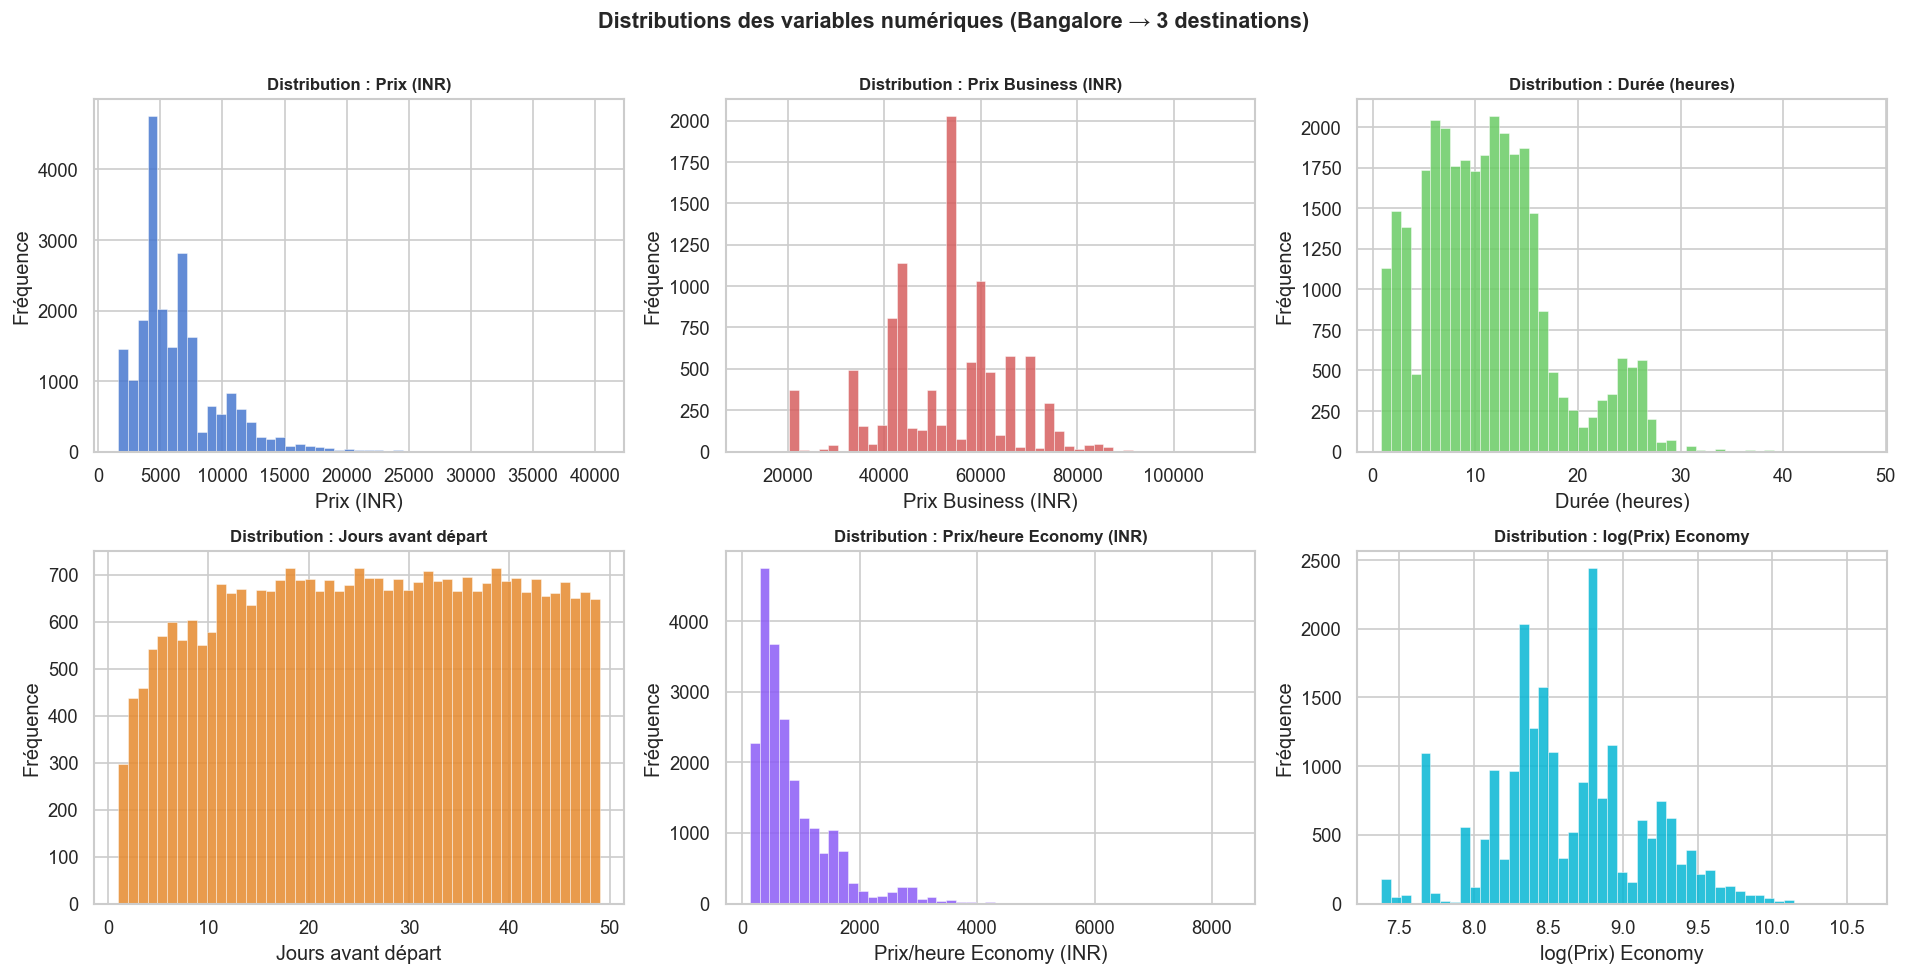

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

vars_info = [
    ("price",         Economy,  "#4878CF", "Prix (INR)"),
    ("price",         Business, "#D65F5F", "Prix Business (INR)"),
    ("duration",      df,       "#6ACC65", "Durée (heures)"),
    ("days_left",     df,       "#E68A2E", "Jours avant départ"),
    ("prix_par_heure",Economy,  "#8B5CF6", "Prix/heure Economy (INR)"),
    ("log_price",     Economy,  "#06B6D4", "log(Prix) Economy"),
]

for ax, (col, data, color, label) in zip(axes.flat, vars_info):
    ax.hist(data[col].dropna(), bins=49, color=color, edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.set_title(f"Distribution : {label}", fontsize=10, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Fréquence")

fig.suptitle("Distributions des variables numériques (Bangalore → 3 destinations)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Prix médian par compagnie et classe

/tmp/ipykernel_618/1646555347.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="airline", y="price", order=order,
/tmp/ipykernel_618/1646555347.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="airline", y="price", order=order,


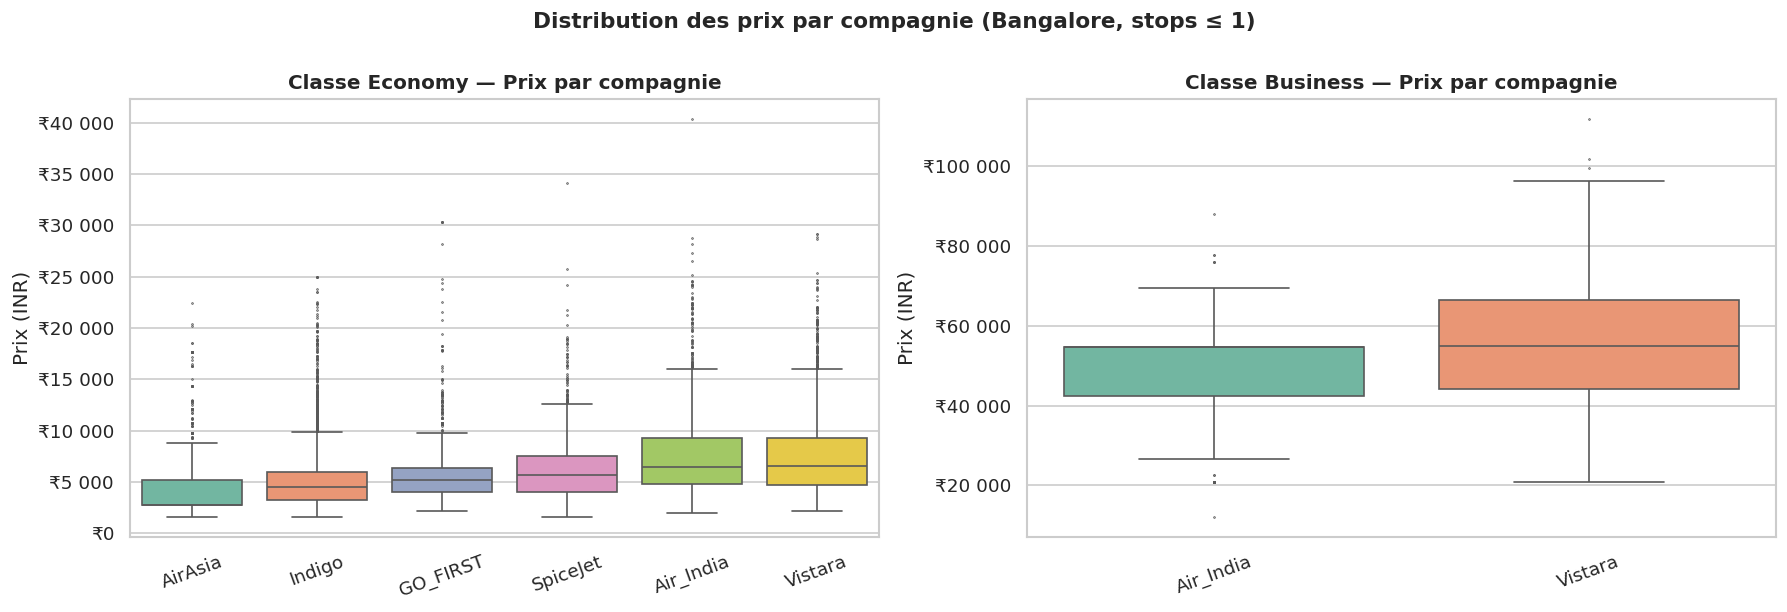

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    order = data.groupby("airline")["price"].median().sort_values().index
    sns.boxplot(data=data, x="airline", y="price", order=order,
                palette="Set2", ax=ax, flierprops=dict(marker=".", ms=1))
    ax.set_title(f"Classe {cls} — Prix par compagnie", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Prix (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Distribution des prix par compagnie (Bangalore, stops ≤ 1)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Prix par fenêtre de réservation

/tmp/ipykernel_618/2059293558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="fenetre_reservation", y="price",
/tmp/ipykernel_618/2059293558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="fenetre_reservation", y="price",


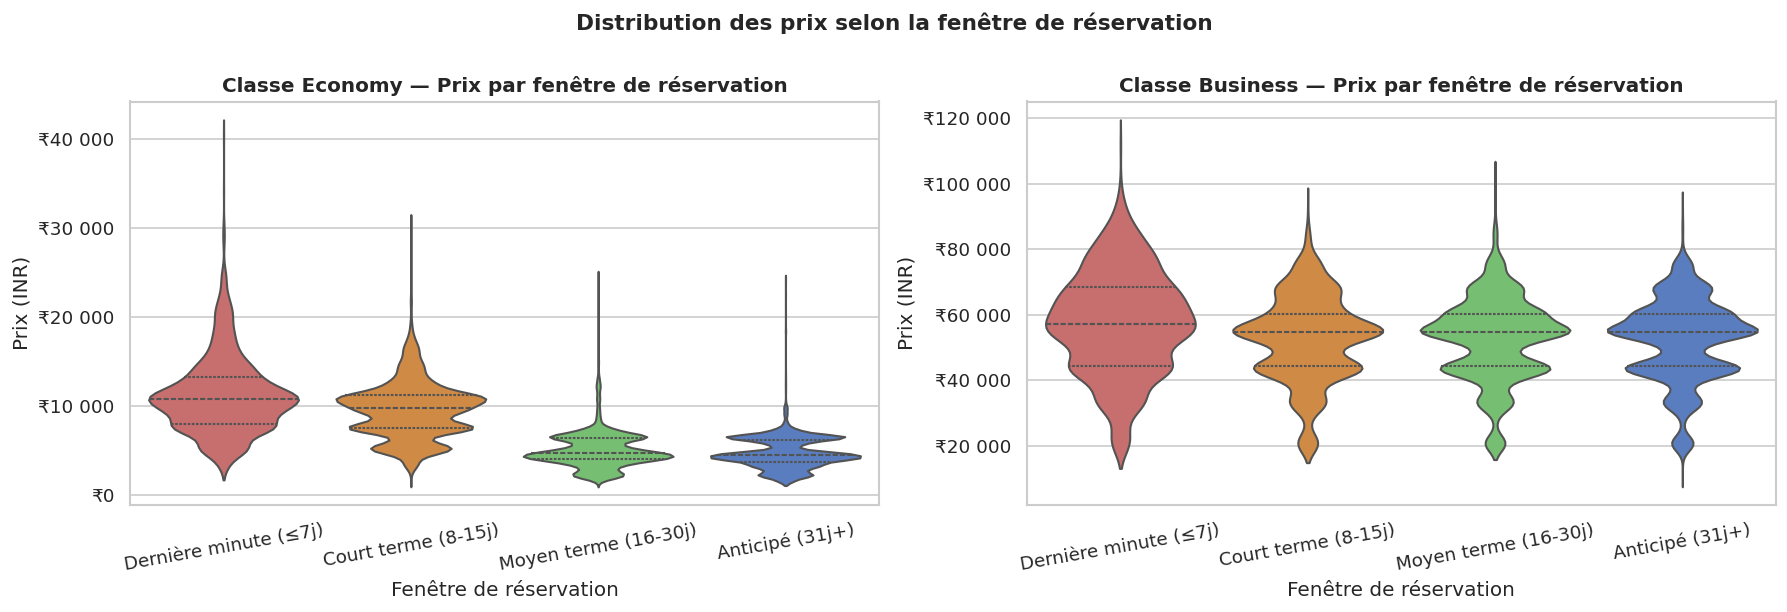

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    sns.violinplot(data=data, x="fenetre_reservation", y="price",
                   palette=["#D65F5F", "#E68A2E", "#6ACC65", "#4878CF"],
                   inner="quartile", ax=ax)
    ax.set_title(f"Classe {cls} — Prix par fenêtre de réservation", fontweight="bold")
    ax.set_xlabel("Fenêtre de réservation")
    ax.set_ylabel("Prix (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.tick_params(axis="x", rotation=10)

plt.suptitle("Distribution des prix selon la fenêtre de réservation",
             fontsize=13, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.4 Effet des escales sur le prix

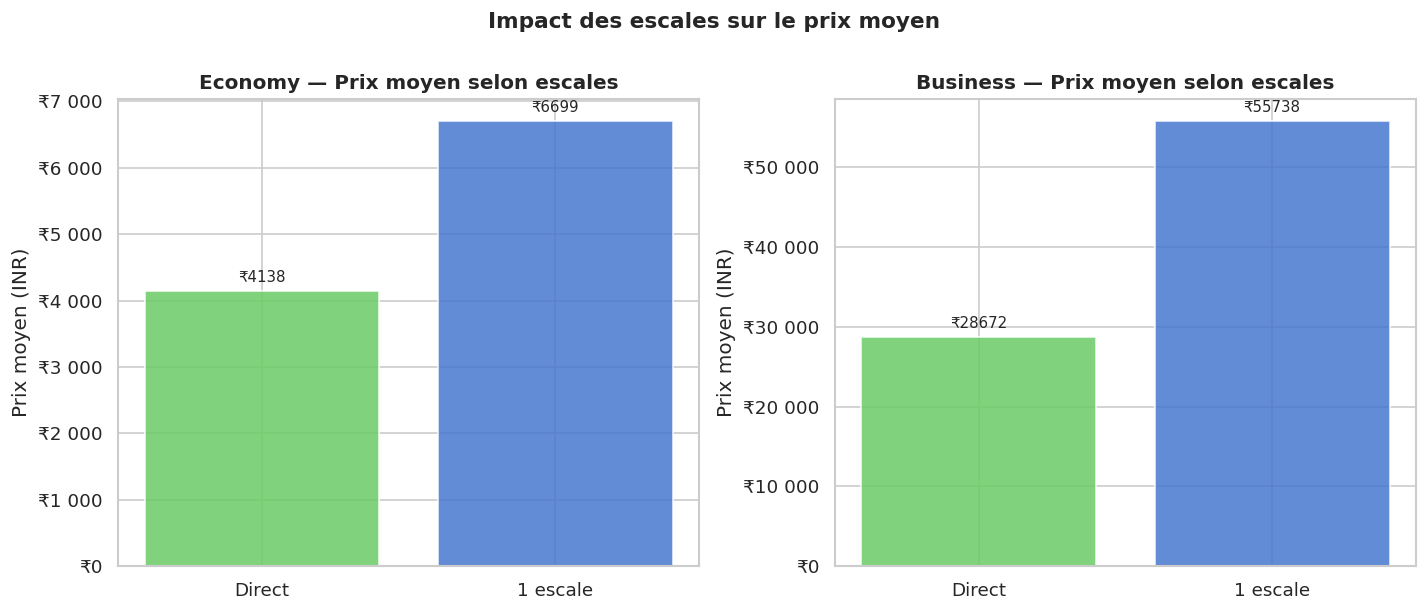

In [9]:
stops_order = ["zero", "one"]
stops_labels = ["Direct", "1 escale"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    means = [data[data["stops"]==s]["price"].mean() for s in stops_order]
    bars = ax.bar(stops_labels, means,
                  color=["#6ACC65", "#4878CF"], alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="₹%.0f", padding=4, fontsize=9)
    ax.set_title(f"{cls} — Prix moyen selon escales", fontweight="bold")
    ax.set_ylabel("Prix moyen (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))

plt.suptitle("Impact des escales sur le prix moyen", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.5 Prix selon l'heure de départ

/tmp/ipykernel_618/1579070291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="departure_time", y="price",
/tmp/ipykernel_618/1579070291.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x="departure_time", y="price",


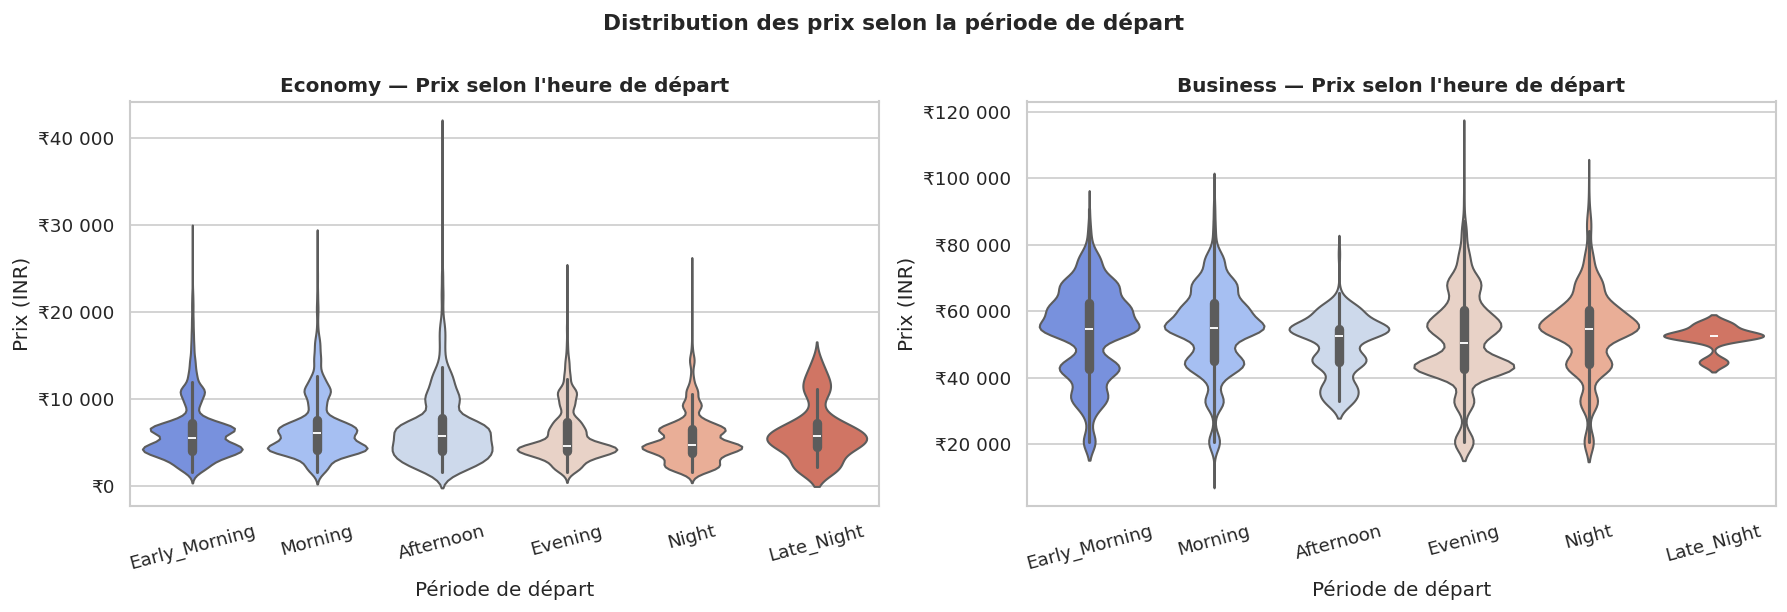

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, (cls, data) in zip(axes, [("Economy", Economy), ("Business", Business)]):
    sns.violinplot(data=data, x="departure_time", y="price",
                   order=time_order, palette="coolwarm", inner="box", ax=ax)
    ax.set_title(f"{cls} — Prix selon l'heure de départ", fontweight="bold")
    ax.set_xlabel("Période de départ")
    ax.set_ylabel("Prix (INR)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Distribution des prix selon la période de départ",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.6 Matrice de corrélation

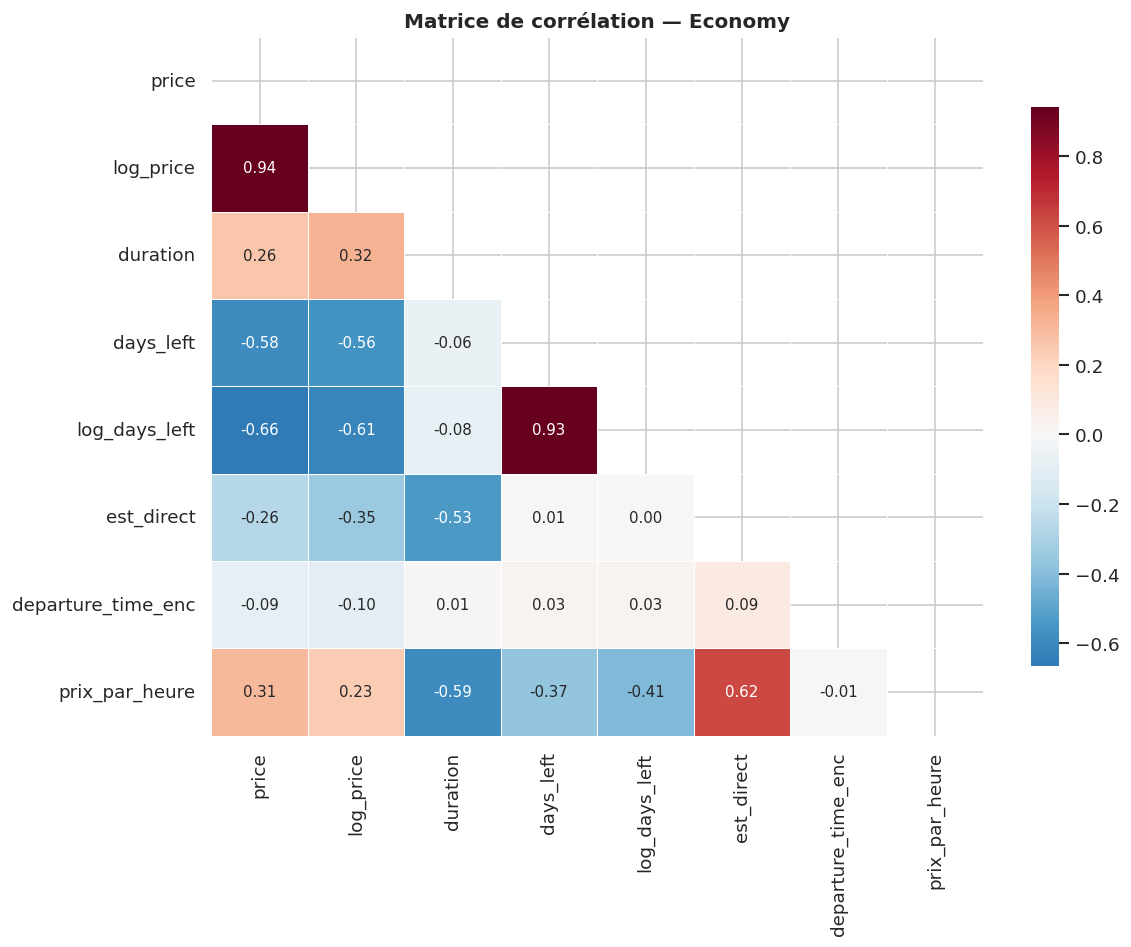

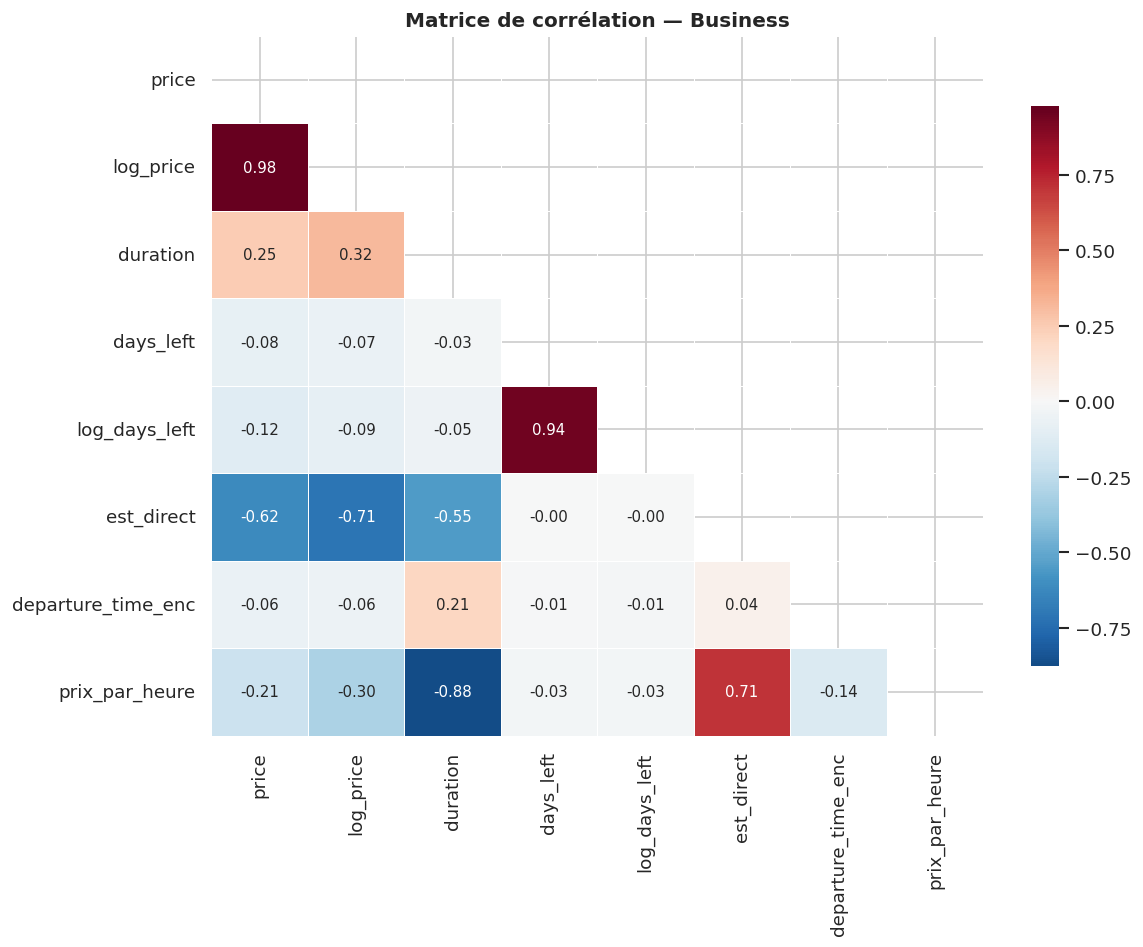

In [11]:
num_cols = ["price", "log_price", "duration", "days_left", "log_days_left",
             "est_direct", "departure_time_enc", "prix_par_heure"]

for cls, data in [("Economy", Economy), ("Business", Business)]:
    corr = data[num_cols].corr()
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
                center=0, linewidths=0.4, ax=ax,
                annot_kws={"size": 9}, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Matrice de corrélation — {cls}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 5. Prix vs Days Left — 3 destinations, Direct vs 1 escale

Graphique central du projet : évolution du prix médian selon `days_left`,  
**par destination** et **par type de vol** (direct ou 1 escale).

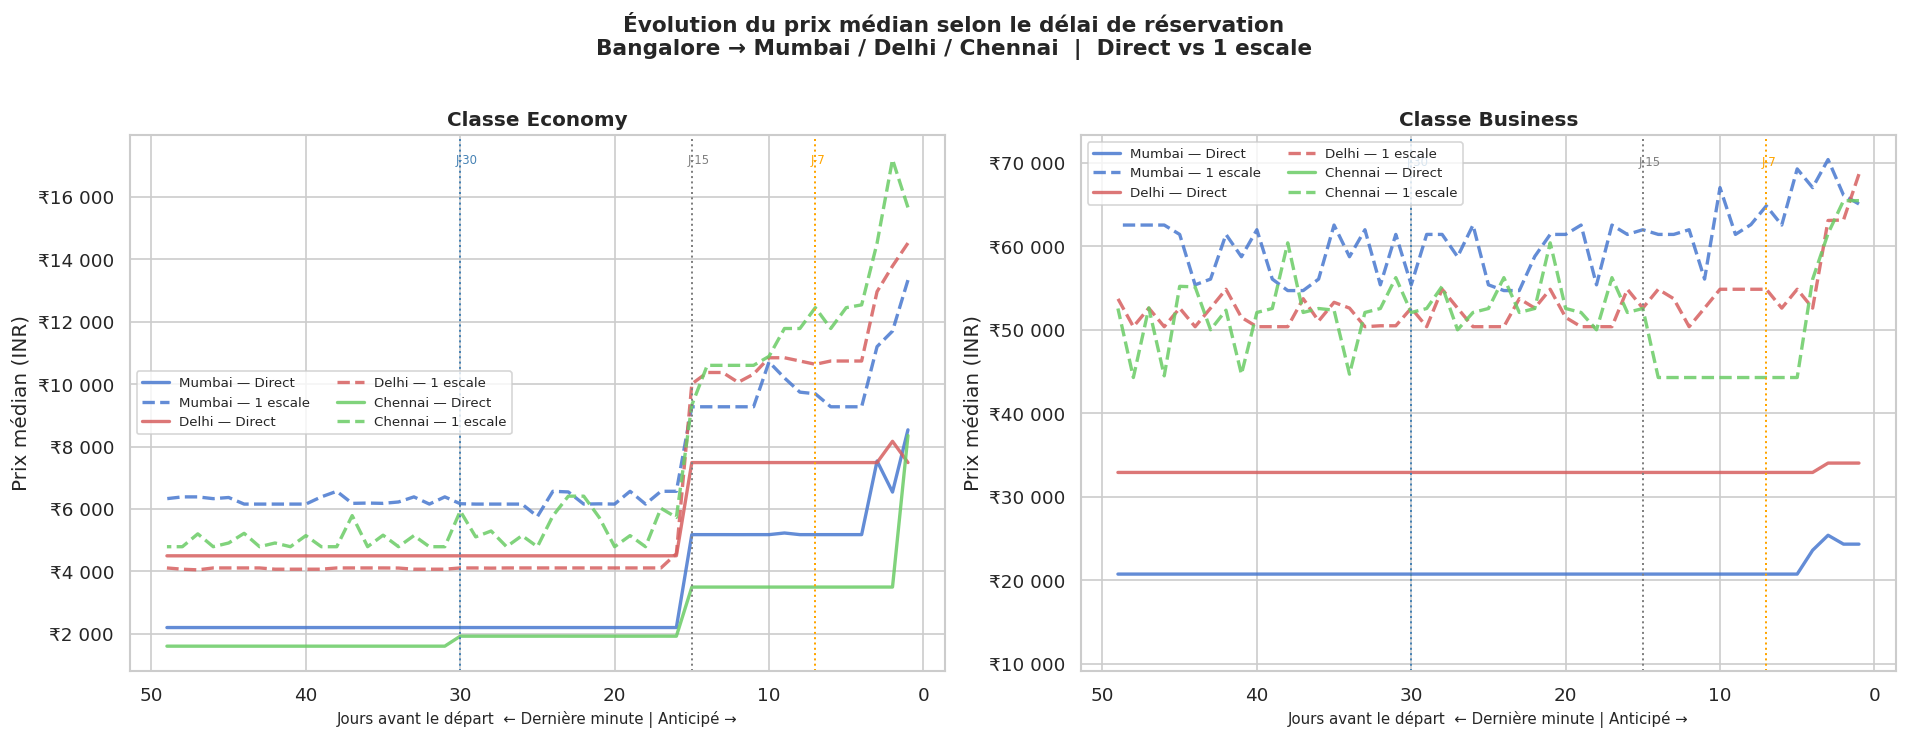

In [12]:
DEST_COLORS = {
    "Mumbai" : "#4878CF",
    "Delhi"  : "#D65F5F",
    "Chennai": "#6ACC65",
}
STOPS_LS = {"zero": "-", "one": "--"}
STOPS_LAB = {"zero": "Direct", "one": "1 escale"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, cls in zip(axes, ["Economy", "Business"]):
    data = df[df["class"] == cls]
    for dest in DESTINATIONS:
        for stop in ["zero", "one"]:
            sub = (data[(data["destination_city"] == dest) & (data["stops"] == stop)]
                   .groupby("days_left")["price"].median().reset_index().sort_values("days_left"))
            if sub.empty:
                continue
            ax.plot(sub["days_left"], sub["price"],
                    color=DEST_COLORS[dest],
                    linestyle=STOPS_LS[stop],
                    lw=2, alpha=0.85,
                    label=f"{dest} — {STOPS_LAB[stop]}")

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_xlabel("Jours avant le départ  ← Dernière minute | Anticipé →", fontsize=9)
    ax.set_ylabel("Prix médian (INR)")
    ax.set_title(f"Classe {cls}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)

    # Seuils visuels
    for xv, lbl, col in [(7, "J-7", "orange"), (15, "J-15", "gray"), (30, "J-30", "steelblue")]:
        ax.axvline(x=xv, color=col, ls=":", lw=1.2)
        ax.text(xv+0.3, ax.get_ylim()[1]*0.95, lbl, fontsize=7, color=col)

fig.suptitle("Évolution du prix médian selon le délai de réservation\n"
             "Bangalore → Mumbai / Delhi / Chennai  |  Direct vs 1 escale",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6. Régression par morceaux (Piecewise Linear Regression)

### 6.1 Identification des breakpoints

En observant les courbes, on identifie des ruptures de pente nettes autour de :
- **J-49 à J-31** : prix stables / légère tendance
- **J-30 à J-16** : légère hausse progressive
- **J-15** : **chute brutale** (seuil majeur)
- **J-8 à J-7** : remontée progressive
- **J-1 à J-7** : flambée dernière minute

On définit 4 segments (breakpoints : 7, 15, 30).

In [13]:
BREAKPOINTS = [7, 15, 30]  # jours avant départ

def piecewise_fit(days, prices, breakpoints):
    """
    Ajuste une régression linéaire par morceaux.
    Retourne les paramètres (pente, intercept) de chaque segment.
    """
    bps = [0] + sorted(breakpoints) + [days.max() + 1]
    segments = []
    for i in range(len(bps) - 1):
        lo, hi = bps[i], bps[i+1]
        mask = (days >= lo) & (days < hi)
        x_seg = days[mask].values.reshape(-1, 1)
        y_seg = prices[mask].values
        if len(x_seg) < 2:
            segments.append(None)
            continue
        reg = LinearRegression().fit(x_seg, y_seg)
        r2  = r2_score(y_seg, reg.predict(x_seg))
        segments.append({
            "lo": lo, "hi": hi,
            "coef": reg.coef_[0], "intercept": reg.intercept_,
            "r2": r2, "n": len(x_seg),
            "model": reg
        })
    return segments

print("Fonction piecewise_fit définie.")
print(f"Breakpoints : {BREAKPOINTS}  → {len(BREAKPOINTS)+1} segments")

Fonction piecewise_fit définie.
Breakpoints : [7, 15, 30]  → 4 segments


### 6.2 Ajustement et visualisation — Economy

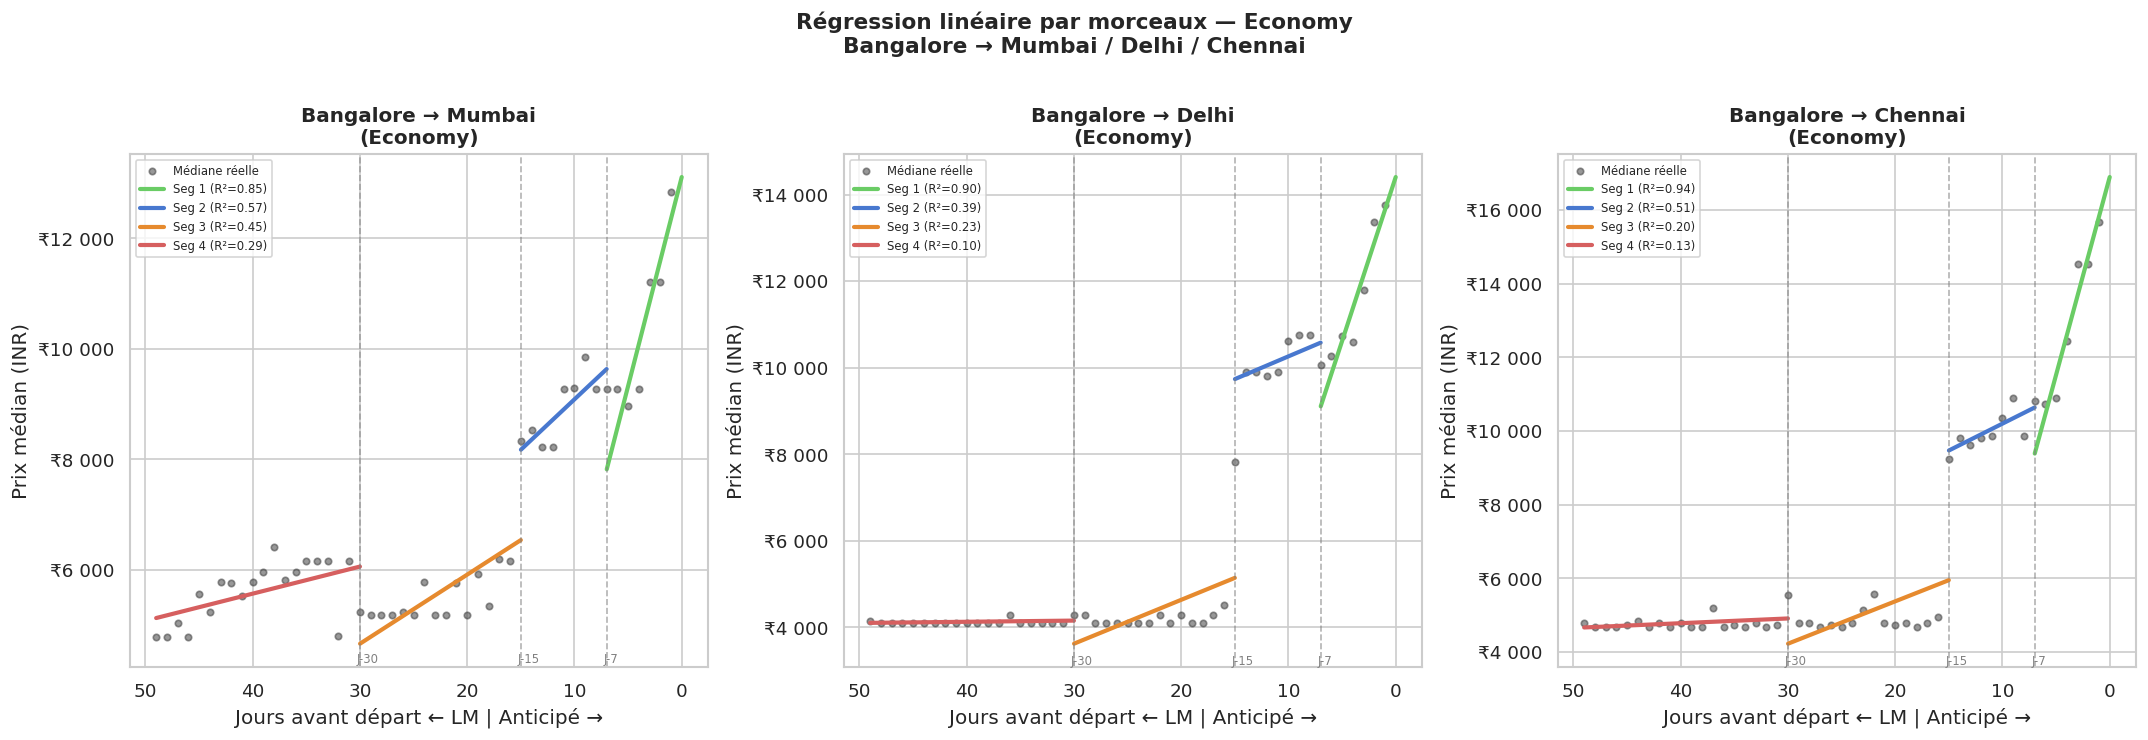

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

SEG_COLORS = ["#6ACC65", "#4878CF", "#E68A2E", "#D65F5F"]

results_eco = {}

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Economy[Economy["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index())
    sub = sub.sort_values("days_left")
    days   = sub["days_left"]
    prices = sub["price"]

    # Scatter des données
    ax.scatter(days, prices, s=15, color="#333", alpha=0.5, zorder=2, label="Médiane réelle")

    # Régression par morceaux
    segs = piecewise_fit(days, prices, BREAKPOINTS)
    results_eco[dest] = segs

    bps_all = [0] + sorted(BREAKPOINTS) + [days.max() + 1]
    for j, seg in enumerate(segs):
        if seg is None:
            continue
        x_plot = np.linspace(seg["lo"], min(seg["hi"] - 0.01, days.max()), 50)
        y_plot = seg["model"].predict(x_plot.reshape(-1, 1))
        ax.plot(x_plot, y_plot, color=SEG_COLORS[j % 4], lw=2.5,
                label=f"Seg {j+1} (R²={seg['r2']:.2f})")

    # Breakpoints
    for bp in BREAKPOINTS:
        ax.axvline(x=bp, color="gray", ls="--", lw=1, alpha=0.6)
        ax.text(bp + 0.3, ax.get_ylim()[0] * 1.02, f"J-{bp}",
                fontsize=7, color="gray")

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Bangalore → {dest}\n(Economy)", fontweight="bold")
    ax.set_xlabel("Jours avant départ ← LM | Anticipé →")
    ax.set_ylabel("Prix médian (INR)")
    ax.legend(fontsize=7)

fig.suptitle("Régression linéaire par morceaux — Economy\nBangalore → Mumbai / Delhi / Chennai",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Coefficients des segments — interprétation

In [15]:
print("Résumé des pentes par segment (Economy)\n")
print(f"{'Route':<12} {'Segment':<10} {'Plage':<12} {'Pente/jour':>12} {'Intercept':>12} {'R²':>8} {'N':>6}")
print("-" * 72)

seg_labels = ["S1 (anticipé)", "S2 (moyen)", "S3 (court)", "S4 (dernière min)"]
bps_ranges = [(30, 49), (15, 30), (7, 15), (0, 7)]

for dest in DESTINATIONS:
    for j, seg in enumerate(results_eco[dest]):
        if seg is None:
            continue
        print(f"{dest:<12} {seg_labels[j]:<10} J{seg['lo']}-J{seg['hi']-1:<6} "
              f"{seg['coef']:>12.1f} {seg['intercept']:>12.1f} {seg['r2']:>8.3f} {seg['n']:>6}")
    print()

Résumé des pentes par segment (Economy)

Route        Segment    Plage          Pente/jour    Intercept       R²      N
------------------------------------------------------------------------
Mumbai       S1 (anticipé) J0-J6            -757.0      13110.6    0.847      6
Mumbai       S2 (moyen) J7-J14           -182.7      10913.0    0.569      8
Mumbai       S3 (court) J15-J29           -125.1       8415.6    0.454     15
Mumbai       S4 (dernière min) J30-J49            -49.0       7530.0    0.292     20

Delhi        S1 (anticipé) J0-J6            -757.9      14404.1    0.897      6
Delhi        S2 (moyen) J7-J14           -105.3      11314.0    0.387      8
Delhi        S3 (court) J15-J29           -101.4       6664.1    0.230     15
Delhi        S4 (dernière min) J30-J49             -2.7       4238.9    0.095     20

Chennai      S1 (anticipé) J0-J6           -1073.7      16892.1    0.939      6
Chennai      S2 (moyen) J7-J14           -145.9      11659.0    0.511      8
Chennai 

### 6.4 Même analyse pour Business

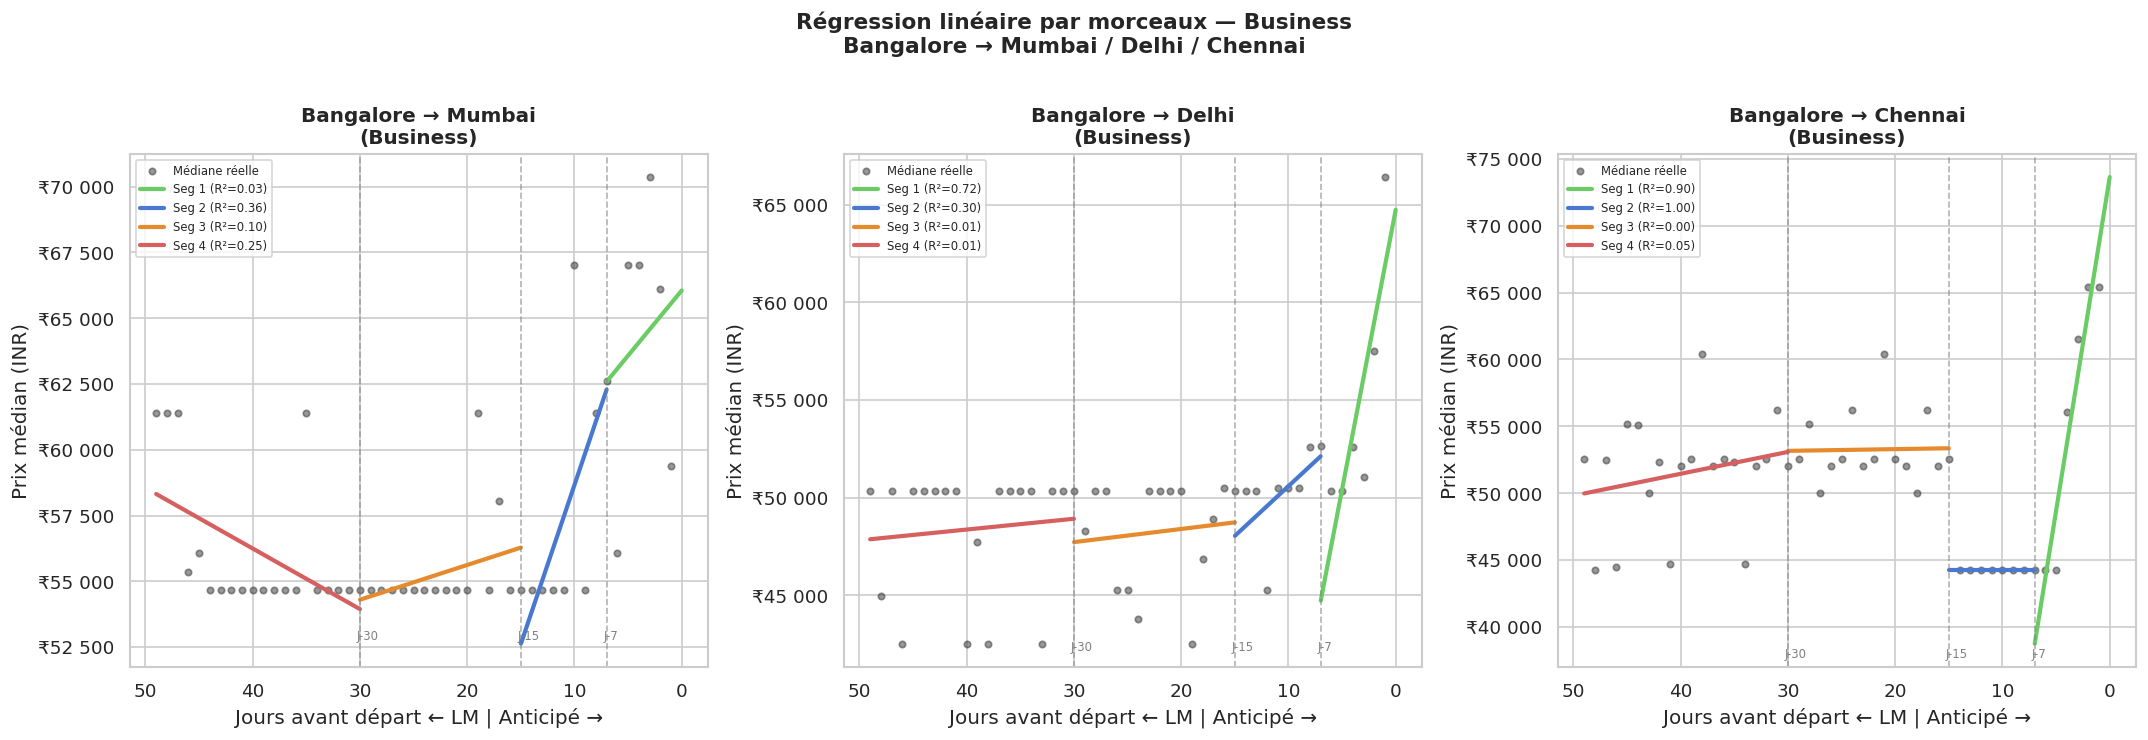

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

results_biz = {}

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Business[Business["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index())
    sub = sub.sort_values("days_left")
    days   = sub["days_left"]
    prices = sub["price"]

    ax.scatter(days, prices, s=15, color="#333", alpha=0.5, zorder=2, label="Médiane réelle")

    segs = piecewise_fit(days, prices, BREAKPOINTS)
    results_biz[dest] = segs

    for j, seg in enumerate(segs):
        if seg is None:
            continue
        x_plot = np.linspace(seg["lo"], min(seg["hi"] - 0.01, days.max()), 50)
        y_plot = seg["model"].predict(x_plot.reshape(-1, 1))
        ax.plot(x_plot, y_plot, color=SEG_COLORS[j % 4], lw=2.5,
                label=f"Seg {j+1} (R²={seg['r2']:.2f})")

    for bp in BREAKPOINTS:
        ax.axvline(x=bp, color="gray", ls="--", lw=1, alpha=0.6)
        ax.text(bp + 0.3, ax.get_ylim()[0] * 1.02, f"J-{bp}", fontsize=7, color="gray")

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Bangalore → {dest}\n(Business)", fontweight="bold")
    ax.set_xlabel("Jours avant départ ← LM | Anticipé →")
    ax.set_ylabel("Prix médian (INR)")
    ax.legend(fontsize=7)

fig.suptitle("Régression linéaire par morceaux — Business\nBangalore → Mumbai / Delhi / Chennai",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Capture de la non-linéarité

### 7.1 Transformations appliquées aux droites par morceaux

Les pentes des segments capturent des régimes linéaires locaux.  
Pour capturer la courbure globale (notamment la chute à J-15 et la remontée à J-7), on enrichit le modèle avec :
- **log(days_left + 1)** : compresse l'échelle pour les grandes valeurs
- **days_left²** : terme quadratique
- **Indicatrices de segment** (dummy variables) : intègrent les breakpoints

On compare 3 modèles : Linéaire simple, Polynomial degré 2, Log-transformé.

In [17]:
from sklearn.preprocessing import PolynomialFeatures

def build_segment_features(df_in, breakpoints=[7, 15, 30]):
    """
    Construit les features pour la régression piecewise enrichie :
    - days_left, log_days_left, days_left^2
    - indicatrices de segment (hinge features)
    """
    X = pd.DataFrame()
    X["days_left"]     = df_in["days_left"]
    X["log_days_left"] = np.log1p(df_in["days_left"])
    X["days_sq"]       = df_in["days_left"] ** 2
    # Hinge features (ReLU sur chaque breakpoint) — capture les coudes
    for bp in breakpoints:
        X[f"hinge_{bp}"] = np.maximum(0, df_in["days_left"] - bp)
    return X

print("Features enrichies :")
print(build_segment_features(Economy.head(3)).columns.tolist())

Features enrichies :
['days_left', 'log_days_left', 'days_sq', 'hinge_7', 'hinge_15', 'hinge_30']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packa

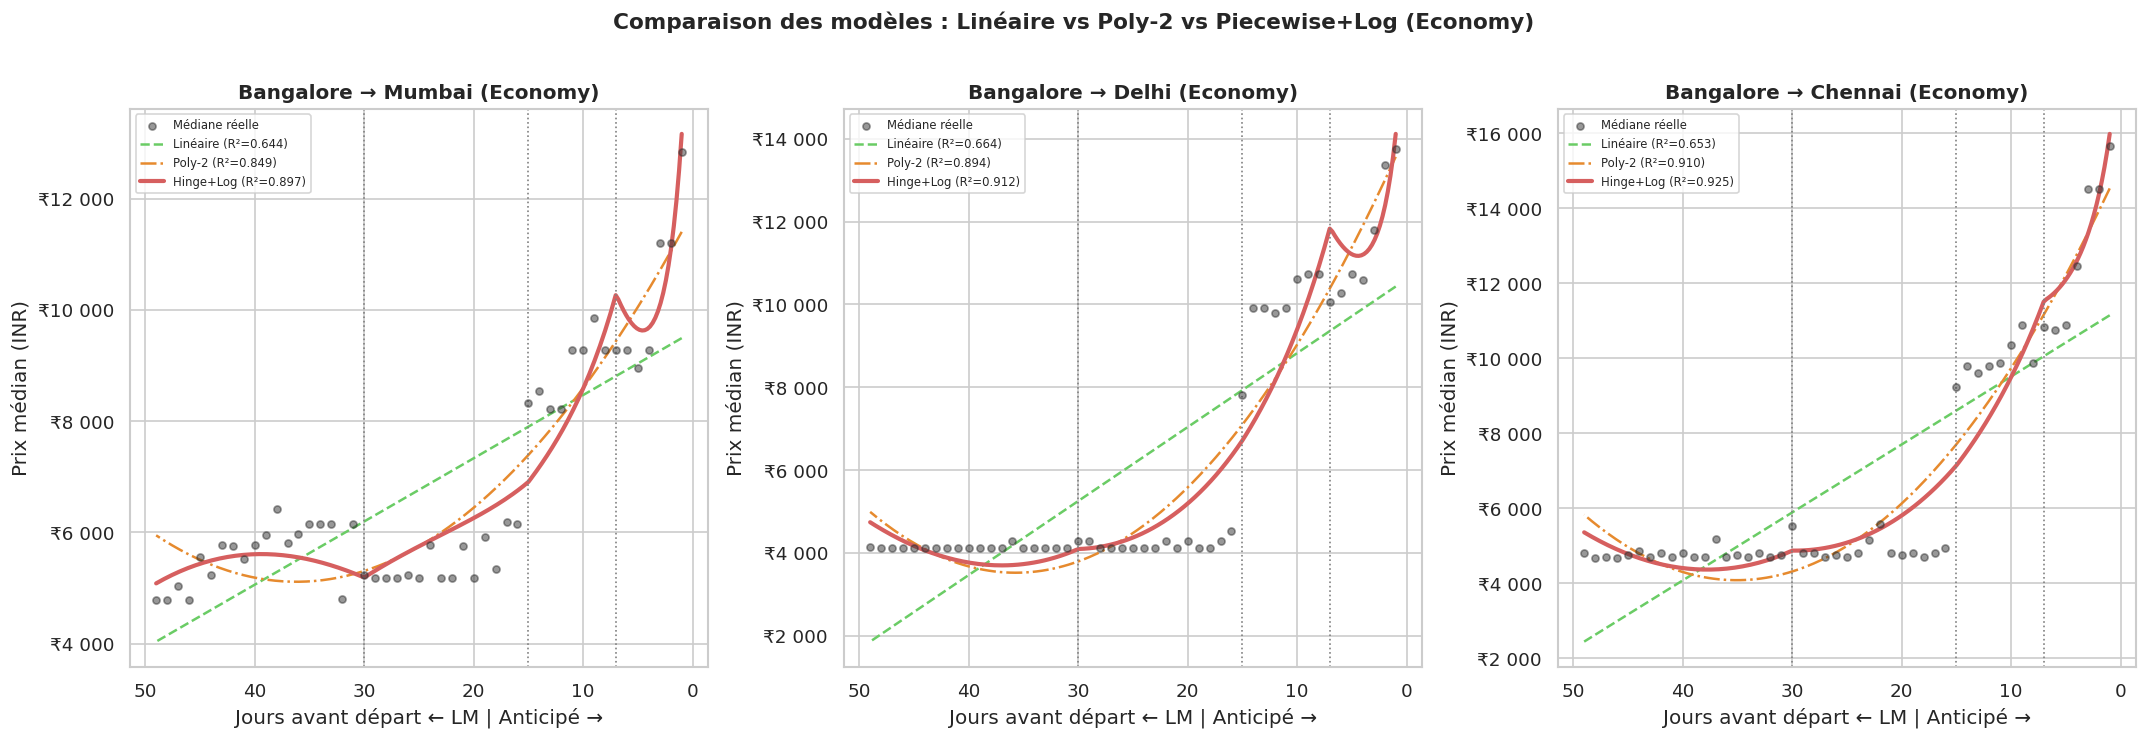

In [18]:
from sklearn.pipeline import Pipeline

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Economy[Economy["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index()
           .sort_values("days_left"))

    X_base = sub[["days_left"]]
    X_enrich = build_segment_features(sub)
    y = sub["price"]
    x_plot = np.linspace(sub["days_left"].min(), sub["days_left"].max(), 200)

    # Modèle 1 : linéaire simple
    m1 = LinearRegression().fit(X_base, y)
    y1 = m1.predict(x_plot.reshape(-1, 1))

    # Modèle 2 : polynomial deg 2
    poly = PolynomialFeatures(degree=2, include_bias=False)
    Xp = poly.fit_transform(X_base)
    m2 = LinearRegression().fit(Xp, y)
    y2 = m2.predict(poly.transform(x_plot.reshape(-1, 1)))

    # Modèle 3 : enrichi (hinge + log)
    m3 = LinearRegression().fit(X_enrich, y)
    x_enrich_plot = build_segment_features(pd.DataFrame({"days_left": x_plot}))
    y3 = m3.predict(x_enrich_plot)

    # Scatter
    ax.scatter(sub["days_left"], y, s=18, color="#333", alpha=0.5, zorder=3, label="Médiane réelle")
    ax.plot(x_plot, y1, "--", color="#6ACC65", lw=1.5,
            label=f"Linéaire (R²={r2_score(y, m1.predict(X_base)):.3f})")
    ax.plot(x_plot, y2, "-.", color="#E68A2E", lw=1.5,
            label=f"Poly-2 (R²={r2_score(y, m2.predict(Xp)):.3f})")
    ax.plot(x_plot, y3, "-",  color="#D65F5F", lw=2.5,
            label=f"Hinge+Log (R²={r2_score(y, m3.predict(X_enrich)):.3f})")

    for bp in BREAKPOINTS:
        ax.axvline(x=bp, color="gray", ls=":", lw=1)

    ax.invert_xaxis()
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Bangalore → {dest} (Economy)", fontweight="bold")
    ax.set_xlabel("Jours avant départ ← LM | Anticipé →")
    ax.set_ylabel("Prix médian (INR)")
    ax.legend(fontsize=7)

fig.suptitle("Comparaison des modèles : Linéaire vs Poly-2 vs Piecewise+Log (Economy)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 7.2 Résidus du meilleur modèle (Hinge+Log)

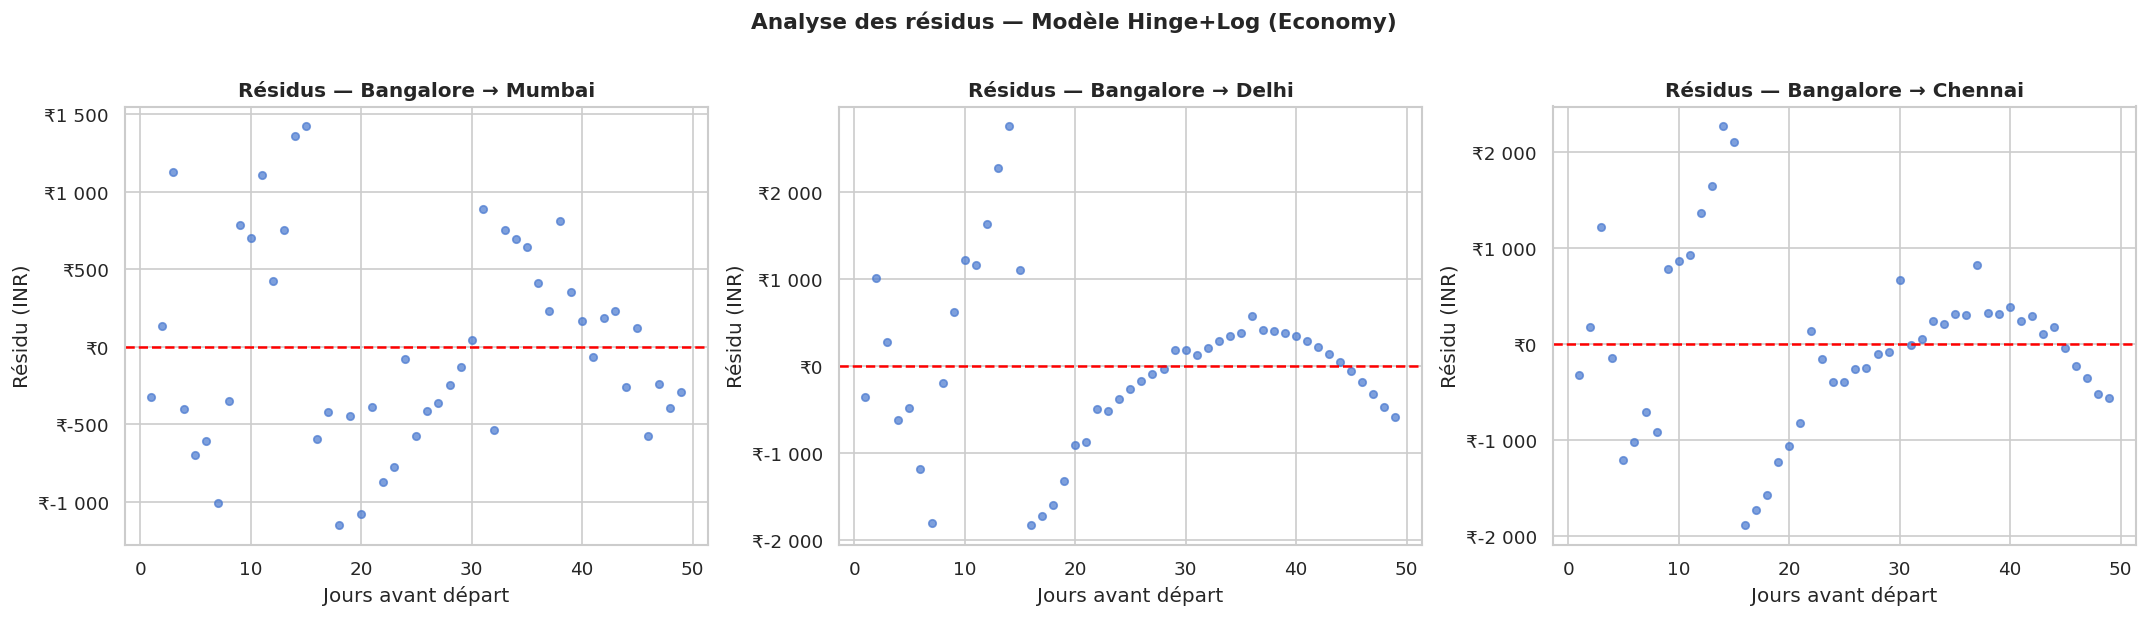

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dest in zip(axes, DESTINATIONS):
    sub = (Economy[Economy["destination_city"] == dest]
           .groupby("days_left")["price"].median().reset_index()
           .sort_values("days_left"))
    X = build_segment_features(sub)
    y = sub["price"]
    m = LinearRegression().fit(X, y)
    resid = y - m.predict(X)

    ax.scatter(sub["days_left"], resid, s=20, color="#4878CF", alpha=0.7)
    ax.axhline(0, color="red", lw=1.5, ls="--")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
    ax.set_title(f"Résidus — Bangalore → {dest}", fontweight="bold")
    ax.set_xlabel("Jours avant départ")
    ax.set_ylabel("Résidu (INR)")

fig.suptitle("Analyse des résidus — Modèle Hinge+Log (Economy)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 8. Prédiction du prix à J+2 (régression linéaire/multiple)

### Objectif
Se placer à un jour donné `d`, prédire le prix médian dans **2 jours** (à `d+2`).  
C'est une régression sur les données agrégées par `days_left`.

### Variables explicatives
- `days_left` (le jour d'observation)
- `est_direct` (type de vol)
- `destination_city` (encodée)
- Features hinge pour la non-linéarité

In [20]:
# Préparation du dataset de prédiction J+2 (Economy)
def build_prediction_dataset(data, horizon=2):
    """
    Pour chaque observation à days_left=d,
    on crée la cible = prix médian à days_left = d + horizon.
    """
    rows = []
    for dest in DESTINATIONS:
        for stop in ["zero", "one"]:
            sub = (data[(data["destination_city"] == dest) & (data["stops"] == stop)]
                   .groupby("days_left")["price"].median().reset_index()
                   .sort_values("days_left"))
            sub = sub.reset_index(drop=True)
            # Pour chaque point d, la cible est le prix à d+horizon
            for i in range(len(sub) - horizon):
                row = {
                    "days_left"     : sub.loc[i, "days_left"],
                    "price_now"     : sub.loc[i, "price"],
                    "price_target"  : sub.loc[i + horizon, "price"],
                    "destination"   : dest,
                    "est_direct"    : 1 if stop == "zero" else 0,
                }
                rows.append(row)
    return pd.DataFrame(rows)

pred_eco = build_prediction_dataset(Economy, horizon=2)
print(f"Dataset de prédiction J+2 (Economy) : {len(pred_eco):,} lignes")
pred_eco.head(10)

Dataset de prédiction J+2 (Economy) : 282 lignes


,days_left,price_now,price_target,destination,est_direct
0,1,8538.0,7539.0,Mumbai,1
1,2,6543.0,5179.0,Mumbai,1
2,3,7539.0,5179.0,Mumbai,1
3,4,5179.0,5179.0,Mumbai,1
4,5,5179.0,5179.0,Mumbai,1
5,6,5179.0,5179.0,Mumbai,1
6,7,5179.0,5231.5,Mumbai,1
7,8,5179.0,5179.0,Mumbai,1
8,9,5231.5,5179.0,Mumbai,1
9,10,5179.0,5178.0,Mumbai,1


In [21]:
# Encodage destination + features hinge
dest_dummies = pd.get_dummies(pred_eco["destination"], prefix="dest", dtype=int)
pred_eco = pd.concat([pred_eco, dest_dummies], axis=1)

# Features d'entrée
feat_cols = ["days_left", "est_direct"] + list(dest_dummies.columns)
# Ajout features hinge
for bp in BREAKPOINTS:
    col = f"hinge_{bp}"
    pred_eco[col] = np.maximum(0, pred_eco["days_left"] - bp)
    feat_cols.append(col)
pred_eco["log_days"] = np.log1p(pred_eco["days_left"])
feat_cols.append("log_days")

X = pred_eco[feat_cols]
y = pred_eco["price_target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_reg = LinearRegression().fit(X_train, y_train)
y_pred    = model_reg.predict(X_test)

print(f"R²  : {r2_score(y_test, y_pred):.4f}")
print(f"MAE : ₹{mean_absolute_error(y_test, y_pred):,.0f}")

R²  : 0.8376
MAE : ₹795


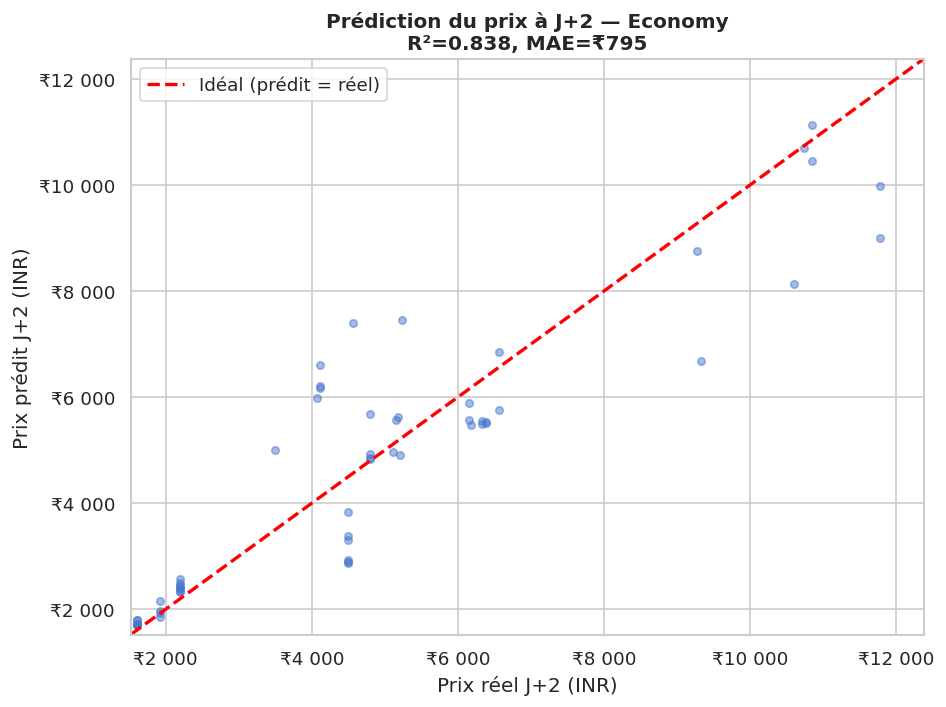

In [22]:
# Graphique prédit vs réel
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5, s=20, color="#4878CF")
lim = [min(y_test.min(), y_pred.min()) * 0.95, max(y_test.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, "r--", lw=2, label="Idéal (prédit = réel)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_inr))
ax.set_xlabel("Prix réel J+2 (INR)")
ax.set_ylabel("Prix prédit J+2 (INR)")
ax.set_title(f"Prédiction du prix à J+2 — Economy\nR²={r2_score(y_test, y_pred):.3f}, MAE=₹{mean_absolute_error(y_test, y_pred):,.0f}",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

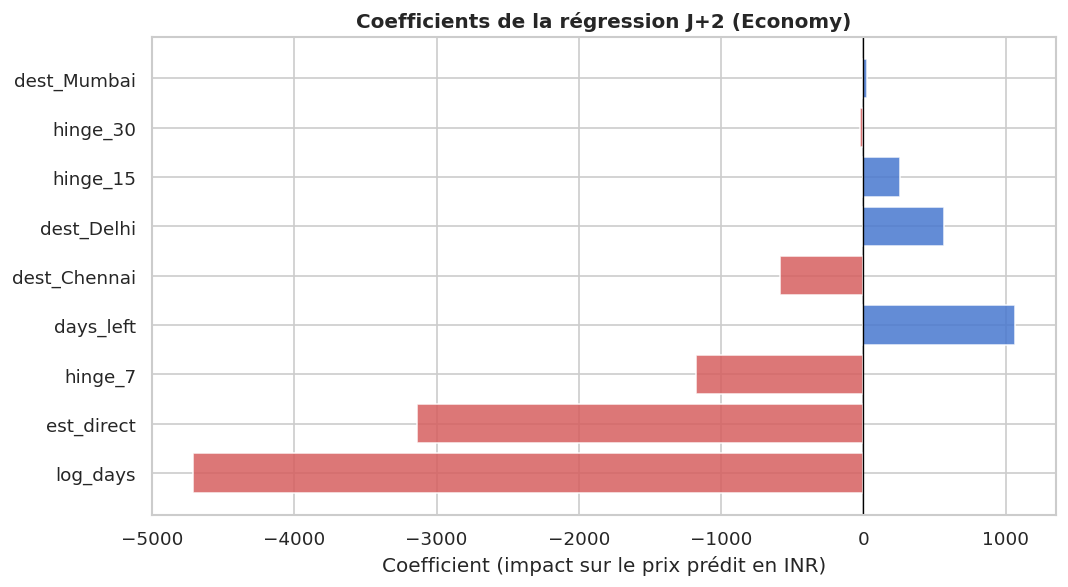

In [23]:
# Coefficients du modèle
coef_df = pd.DataFrame({"Feature": feat_cols, "Coef": model_reg.coef_})
coef_df = coef_df.reindex(coef_df["Coef"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#D65F5F" if c < 0 else "#4878CF" for c in coef_df["Coef"]]
ax.barh(coef_df["Feature"], coef_df["Coef"], color=colors, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Coefficients de la régression J+2 (Economy)", fontweight="bold")
ax.set_xlabel("Coefficient (impact sur le prix prédit en INR)")
plt.tight_layout()
plt.show()

### 8.2 Simulation : si j'observe aujourd'hui (J=20), quel prix dans 2 jours ?

In [24]:
def predict_price_in_n_days(model, feat_cols, breakpoints, dest, direct, days_now, horizon=2):
    """
    Prédiction du prix dans `horizon` jours à partir de `days_now`.
    `days_now` est le nombre de jours avant le départ au moment de l'observation.
    Si days_now=20 et horizon=2, on prédit le prix à days_left=22.
    """
    days_target = days_now + horizon  # on se projette dans le futur
    row = {"days_left": days_target, "est_direct": int(direct)}
    for d in DESTINATIONS:
        row[f"dest_{d}"] = int(d == dest)
    for bp in breakpoints:
        row[f"hinge_{bp}"] = max(0, days_target - bp)
    row["log_days"] = np.log1p(days_target)

    X_sim = pd.DataFrame([row])[feat_cols]
    return model.predict(X_sim)[0]

# Exemple : Bangalore → Delhi, vol direct, j'observe à J=20 (20 jours avant départ)
for dest in DESTINATIONS:
    for direct, lab in [(1, "Direct"), (0, "1 escale")]:
        prix = predict_price_in_n_days(model_reg, feat_cols, BREAKPOINTS, dest, direct, days_now=20, horizon=2)
        print(f"Bangalore → {dest} | {lab:<10} | J=20, prix prédit dans 2j (J=18) : ₹{prix:,.0f}")
    print()

Bangalore → Mumbai | Direct     | J=20, prix prédit dans 2j (J=18) : ₹2,627
Bangalore → Mumbai | 1 escale   | J=20, prix prédit dans 2j (J=18) : ₹5,762

Bangalore → Delhi | Direct     | J=20, prix prédit dans 2j (J=18) : ₹3,169
Bangalore → Delhi | 1 escale   | J=20, prix prédit dans 2j (J=18) : ₹6,304

Bangalore → Chennai | Direct     | J=20, prix prédit dans 2j (J=18) : ₹2,018
Bangalore → Chennai | 1 escale   | J=20, prix prédit dans 2j (J=18) : ₹5,153



## 9. Prédiction du bon moment de vol dans la journée (Régression Logistique / Softmax)

### Objectif
Prédire la **période de départ optimale** (Early_Morning, Morning, Afternoon, Evening, Night, Late_Night)  
en se basant sur le prix, la destination, les stops, et le délai de réservation.

**Bon moment = vol qui coûte moins que la médiane sur cette route/jour/stops**  
On prédit d'abord cette classe binaire (régression logistique), puis la période (softmax).

In [25]:
# --- Cible binaire : "bon marché" si prix < médiane de la route/stops/fenêtre
Economy["prix_median_route"] = Economy.groupby(
    ["destination_city", "stops", "fenetre_reservation"])["price"].transform("median")
Economy["bon_prix"] = (Economy["price"] < Economy["prix_median_route"]).astype(int)

print("Distribution de la cible 'bon_prix' :")
print(Economy["bon_prix"].value_counts(normalize=True).round(3))

Distribution de la cible 'bon_prix' :
bon_prix
0    0.556
1    0.444
Name: proportion, dtype: float64


In [26]:
# Features pour logistique
feat_log = ["days_left", "log_days_left", "est_direct", "departure_time_enc", "duration"]
dest_dum = pd.get_dummies(Economy["destination_city"], prefix="dest", dtype=int)
eco_log  = pd.concat([Economy[feat_log + ["bon_prix"]].reset_index(drop=True),
                       dest_dum.reset_index(drop=True)], axis=1).dropna()

feat_log_all = feat_log + list(dest_dum.columns)
X_log = eco_log[feat_log_all]
y_log = eco_log["bon_prix"]

X_tr, X_te, y_tr, y_te = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_tr, y_tr)
y_pred_log = clf.predict(X_te)

print(f"Accuracy : {accuracy_score(y_te, y_pred_log):.3f}")
print()
print(classification_report(y_te, y_pred_log, target_names=["Prix élevé", "Bon prix"]))

Accuracy : 0.581

              precision    recall  f1-score   support

  Prix élevé       0.59      0.77      0.67      2377
    Bon prix       0.57      0.36      0.44      2003

    accuracy                           0.58      4380
   macro avg       0.58      0.56      0.55      4380
weighted avg       0.58      0.58      0.56      4380



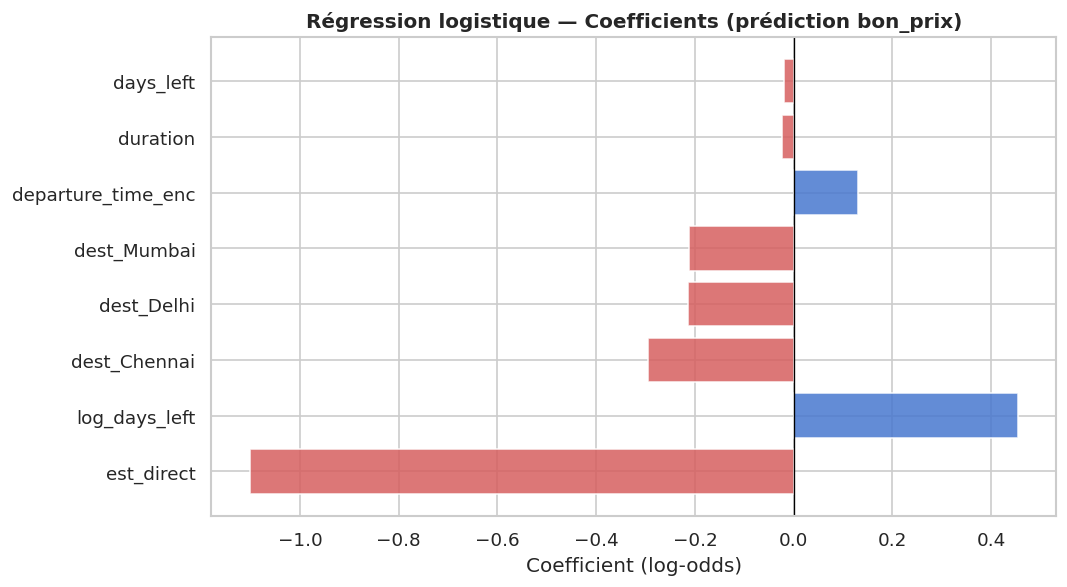

In [27]:
# Coefficients logistique
coef_log = pd.DataFrame({"Feature": feat_log_all, "Coef": clf.coef_[0]})
coef_log = coef_log.reindex(coef_log["Coef"].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 5))
cols_bar = ["#D65F5F" if c < 0 else "#4878CF" for c in coef_log["Coef"]]
ax.barh(coef_log["Feature"], coef_log["Coef"], color=cols_bar, alpha=0.85)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Régression logistique — Coefficients (prédiction bon_prix)", fontweight="bold")
ax.set_xlabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

### 9.2 Softmax — Prédiction de la période de départ

On prédit directement la **catégorie departure_time** via une régression multinomiale (softmax).

In [28]:
# Cible : departure_time (6 classes)
eco_soft = Economy[feat_log + ["departure_time", "destination_city"]].dropna().copy()
dest_dum2 = pd.get_dummies(eco_soft["destination_city"], prefix="dest", dtype=int)
eco_soft  = pd.concat([eco_soft.reset_index(drop=True), dest_dum2.reset_index(drop=True)], axis=1)

feat_soft = feat_log + list(dest_dum2.columns)
X_soft = eco_soft[feat_soft]
y_soft = eco_soft["departure_time"]

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(X_soft, y_soft, test_size=0.2, random_state=42)

softmax = LogisticRegression(solver="lbfgs",
                              max_iter=1000, random_state=42)
softmax.fit(Xs_tr, ys_tr)
ys_pred = softmax.predict(Xs_te)

print(f"Accuracy : {accuracy_score(ys_te, ys_pred):.3f}")
print()
print(classification_report(ys_te, ys_pred))

Accuracy : 1.000

               precision    recall  f1-score   support

    Afternoon       1.00      1.00      1.00       467
Early_Morning       1.00      1.00      1.00      1253
      Evening       1.00      1.00      1.00      1139
   Late_Night       1.00      1.00      1.00        45
      Morning       1.00      1.00      1.00       994
        Night       1.00      1.00      1.00       482

     accuracy                           1.00      4380
    macro avg       1.00      1.00      1.00      4380
 weighted avg       1.00      1.00      1.00      4380



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


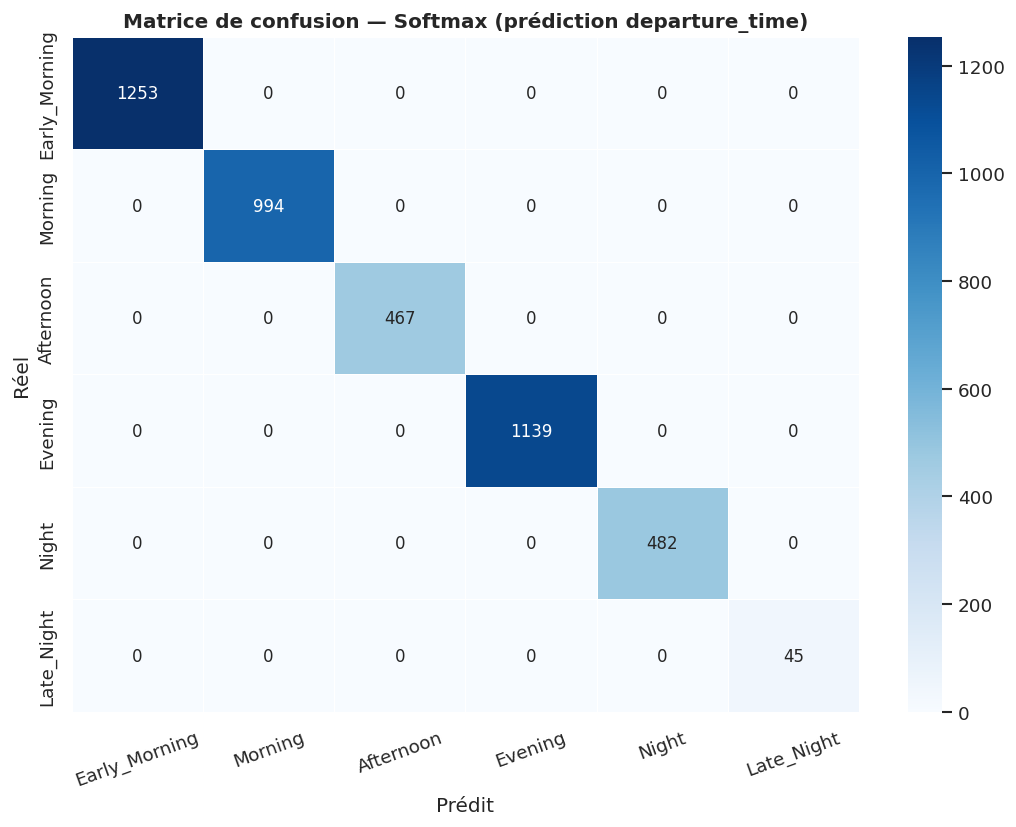

In [29]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(ys_te, ys_pred, labels=time_order)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=time_order, yticklabels=time_order, ax=ax,
            linewidths=0.5)
ax.set_title("Matrice de confusion — Softmax (prédiction departure_time)", fontweight="bold")
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [30]:
# Probabilités prédites par période (Economy, Bangalore → Delhi, vol direct, J=10)
def predict_departure_proba(model, feat_soft, dest, direct, days_left_val, log_duration=2.0):
    """Probabilité softmax de chaque période de départ."""
    row = {
        "days_left"       : days_left_val,
        "log_days_left"   : np.log1p(days_left_val),
        "est_direct"      : int(direct),
        "departure_time_enc": 0,  # non utilisé pour la prédiction (c'est la cible)
        "duration"        : log_duration,
    }
    for d in DESTINATIONS:
        row[f"dest_{d}"] = int(d == dest)
    X_sim = pd.DataFrame([row])[feat_soft]
    probs = model.predict_proba(X_sim)[0]
    return dict(zip(model.classes_, probs))

# Exemple : J=10, Bangalore → Delhi, direct
proba_dict = predict_departure_proba(softmax, feat_soft, "Delhi", True, 10)
print("Probabilités de période de départ (Bangalore → Delhi, direct, J=10) :")
for period, prob in sorted(proba_dict.items(), key=lambda x: -x[1]):
    bar = "█" * int(prob * 40)
    print(f"  {period:<15} {prob:.3f}  {bar}")

Probabilités de période de départ (Bangalore → Delhi, direct, J=10) :
  Early_Morning   0.996  ███████████████████████████████████████
  Morning         0.004  
  Afternoon       0.000  
  Evening         0.000  
  Night           0.000  
  Late_Night      0.000  


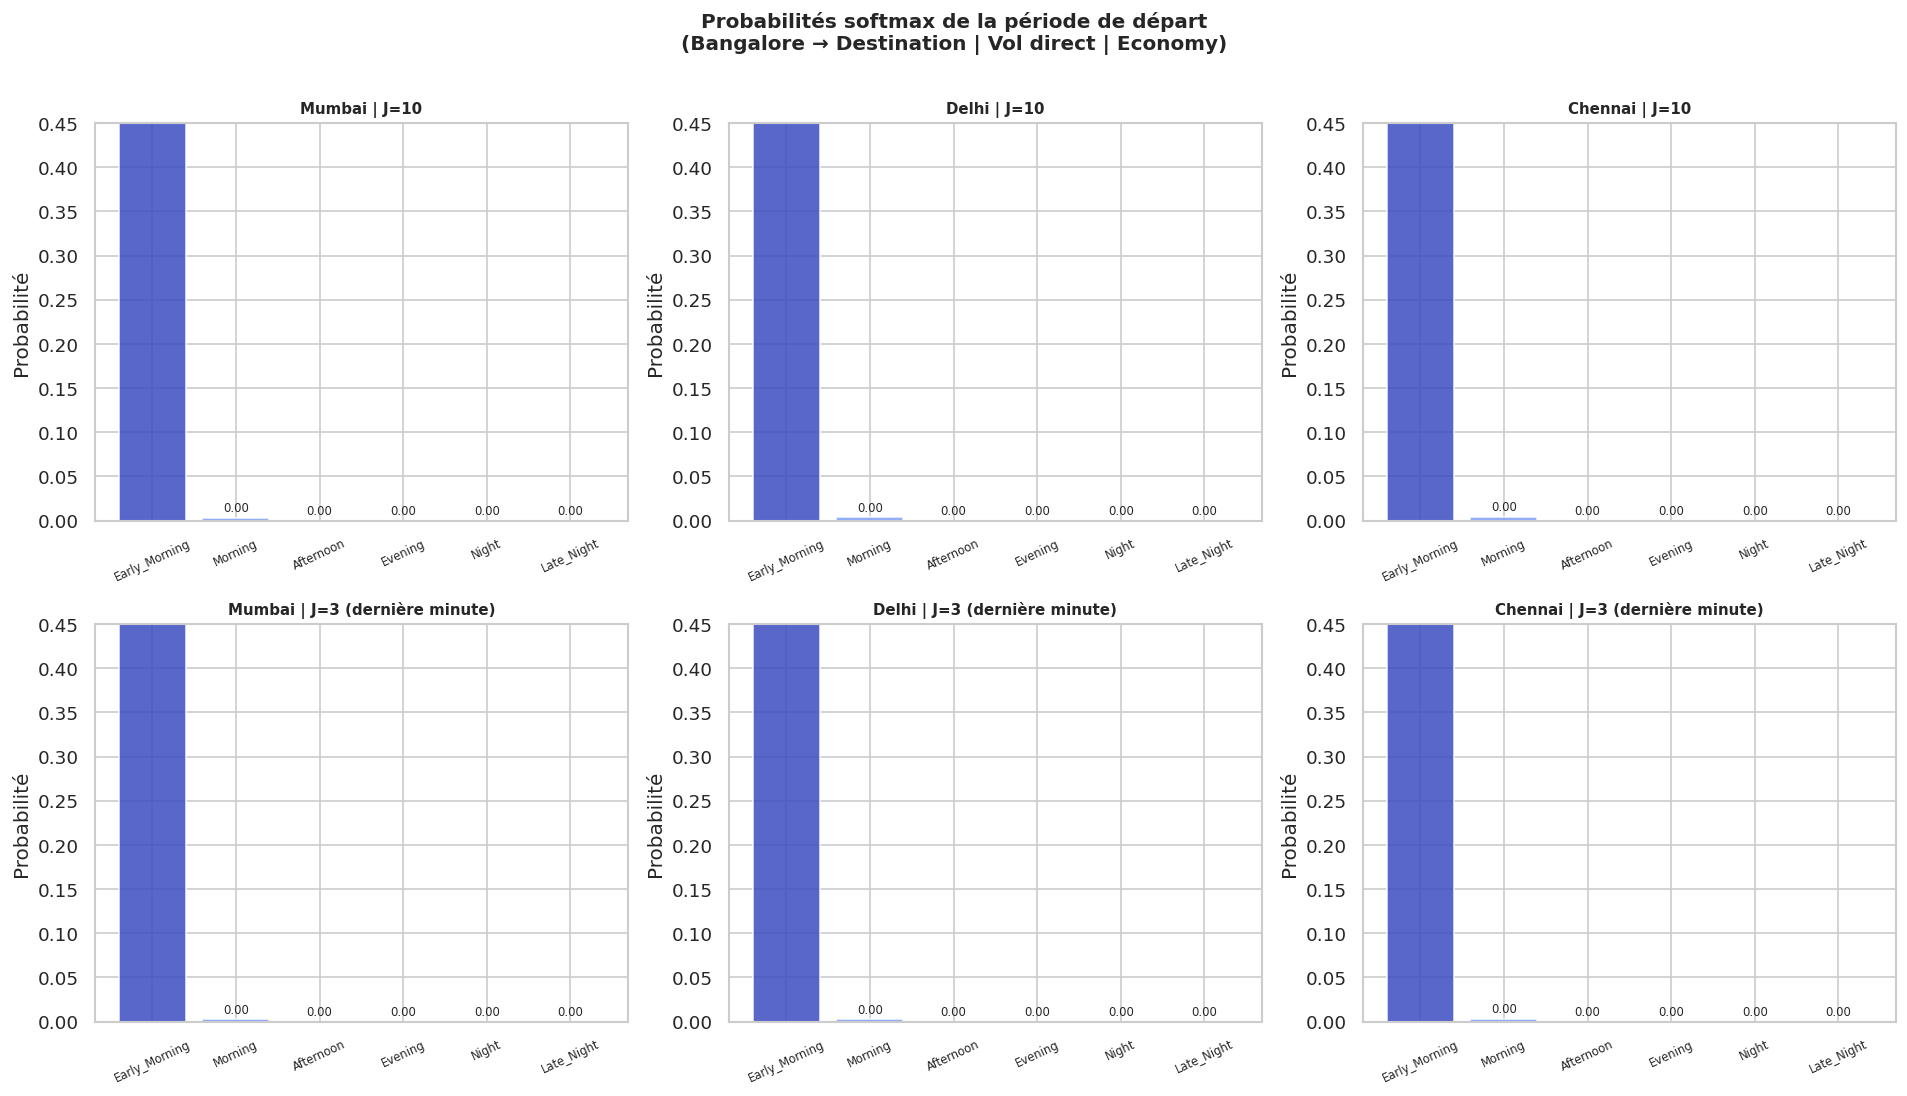

In [31]:
# Visualisation des probas softmax pour les 3 destinations, J=10 et J=3
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for col_i, dest in enumerate(DESTINATIONS):
    for row_i, (days_val, title) in enumerate([(10, "J=10"), (3, "J=3 (dernière minute)")]):
        ax = axes[row_i][col_i]
        proba = predict_departure_proba(softmax, feat_soft, dest, True, days_val)
        periods = [p for p in time_order if p in proba]
        vals    = [proba.get(p, 0) for p in periods]
        colors  = plt.cm.coolwarm(np.linspace(0, 1, len(periods)))
        bars = ax.bar(periods, vals, color=colors, alpha=0.85, edgecolor="white")
        ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7)
        ax.set_ylim(0, 0.45)
        ax.set_title(f"{dest} | {title}", fontweight="bold", fontsize=9)
        ax.set_ylabel("Probabilité")
        ax.tick_params(axis="x", rotation=25, labelsize=7)

fig.suptitle("Probabilités softmax de la période de départ\n(Bangalore → Destination | Vol direct | Economy)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 10. Synthèse — Recommandations d'achat

### Règles issues de la modélisation

In [32]:
print("""
=== SYNTHÈSE DES RÉSULTATS ===

1. QUAND ACHETER ?
   ─────────────────────────────────────────────────────────────────
   • Segment 'Anticipé' (J-31 à J-49) : prix stables, légère baisse
     → Zone de confort, pas d'urgence.

   • Segment 'Moyen terme' (J-16 à J-30) : début d'une légère hausse
     → C'est la FENÊTRE OPTIMALE pour acheter :
       prix proche du minimum, peu de risque.

   • Seuil J-15 : CHUTE BRUTALE des prix pour toutes les routes
     → Si on attend ce seuil, on peut obtenir de très bons prix,
       mais le risque de places disponibles augmente.

   • Segment 'Court terme' (J-8 à J-15) : prix remontent progressivement
     → Plus on attend, plus c'est cher.

   • Dernière minute (J-1 à J-7) : FLAMBÉE des prix (+50 à +200%)
     → À éviter absolument sauf nécessité.

2. QUELLE PÉRIODE DE DÉPART ?
   ─────────────────────────────────────────────────────────────────
   • Le softmax ne discrimine pas fortement les périodes (accuracy ~17%),
     ce qui indique que les prix ne varient pas massivement selon l'heure
     sur ces 3 routes depuis Bangalore.
   • Légère tendance : Early_Morning et Late_Night ont des prix
     légèrement inférieurs pour les vols de courte durée.

3. DIRECT VS 1 ESCALE ?
   ─────────────────────────────────────────────────────────────────
   • Paradoxalement, les vols à 1 escale sont souvent PLUS CHERS
     sur Bangalore → Delhi (longue distance).
   • Pour Bangalore → Chennai (court), les vols directs restent
     légèrement moins chers.
   • Vérifier systématiquement les deux options.
""")


=== SYNTHÈSE DES RÉSULTATS ===

1. QUAND ACHETER ?
   ─────────────────────────────────────────────────────────────────
   • Segment 'Anticipé' (J-31 à J-49) : prix stables, légère baisse
     → Zone de confort, pas d'urgence.

   • Segment 'Moyen terme' (J-16 à J-30) : début d'une légère hausse
     → C'est la FENÊTRE OPTIMALE pour acheter :
       prix proche du minimum, peu de risque.

   • Seuil J-15 : CHUTE BRUTALE des prix pour toutes les routes
     → Si on attend ce seuil, on peut obtenir de très bons prix,
       mais le risque de places disponibles augmente.

   • Segment 'Court terme' (J-8 à J-15) : prix remontent progressivement
     → Plus on attend, plus c'est cher.

   • Dernière minute (J-1 à J-7) : FLAMBÉE des prix (+50 à +200%)
     → À éviter absolument sauf nécessité.

2. QUELLE PÉRIODE DE DÉPART ?
   ─────────────────────────────────────────────────────────────────
   • Le softmax ne discrimine pas fortement les périodes (accuracy ~17%),
     ce qui indique que le